<a href="https://colab.research.google.com/github/san031/Machine_learning-Artificial-Intelligence-Projects/blob/main/machine_learning/linear_regression/HousingAccuracy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/sample_data/housing.csv')

In [ ]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
df['ocean_proximity'].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [ ]:
df['latitude'].value_counts()

,count
latitude,
34.06,241
34.08,232
34.05,229
34.07,227
34.04,215
...,...
41.28,1
35.86,1
35.85,1


,count
latitude,
34.06,241
34.08,232
34.05,229
34.07,227
34.04,215
...,...
41.28,1
35.86,1
35.85,1


In [ ]:
df['latitude'].unique()

array([37.88, 37.86, 37.85, 37.84, 37.83, 37.82, 37.81, 37.8 , 37.79,
       37.77, 37.78, 37.76, 37.75, 37.74, 37.73, 37.9 , 37.89, 37.87,
       37.72, 37.71, 37.7 , 37.69, 37.68, 37.64, 37.63, 37.66, 37.65,
       37.67, 37.61, 37.62, 37.6 , 37.59, 37.58, 37.57, 37.49, 37.52,
       37.56, 37.55, 37.54, 37.53, 37.51, 37.48, 37.47, 37.5 , 38.69,
       38.72, 38.52, 38.48, 38.45, 38.46, 38.43, 38.55, 38.54, 38.51,
       38.5 , 38.47, 38.44, 38.42, 38.37, 38.34, 38.32, 38.26, 38.38,
       38.4 , 38.39, 38.36, 38.31, 39.76, 39.78, 39.77, 39.74, 39.75,
       39.73, 39.71, 39.72, 39.7 , 39.82, 39.79, 39.68, 39.64, 39.59,
       39.88, 40.06, 39.97, 39.86, 39.83, 39.8 , 39.66, 39.69, 39.61,
       39.65, 39.55, 39.52, 39.53, 39.6 , 39.54, 39.5 , 39.49, 39.51,
       39.48, 39.47, 39.45, 39.44, 39.43, 39.4 , 39.39, 39.33, 39.37,
       39.35, 39.34, 39.32, 39.36, 39.38, 39.42, 39.41, 38.15, 38.12,
       38.09, 38.07, 37.97, 38.24, 38.2 , 38.16, 38.11, 38.28, 38.19,
       38.25, 38.41,

In [ ]:
df['housing_median_age'].value_counts()

,count
housing_median_age,
52.0,1265
36.0,856
35.0,818
16.0,762
17.0,694
34.0,682
26.0,611
33.0,609
25.0,562


In [ ]:
df['total_bedrooms'].fillna(df["total_bedrooms"].median(), inplace=True)

/tmp/ipykernel_673/3845276123.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_bedrooms'].fillna(df["total_bedrooms"].median(), inplace=True)


In [ ]:
df['housing_median_age'].unique()

array([41., 21., 52., 42., 50., 40., 49., 48., 51., 43.,  2., 46., 26.,
       20., 17., 36., 19., 23., 38., 35., 10., 16., 27., 39., 31., 29.,
       22., 37., 28., 34., 32., 47., 44., 30., 18., 45., 33., 24., 15.,
       14., 13., 25.,  5., 12.,  6.,  8.,  9.,  7.,  3.,  4., 11.,  1.])

In [ ]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [ ]:
df = df.dropna()

In [ ]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

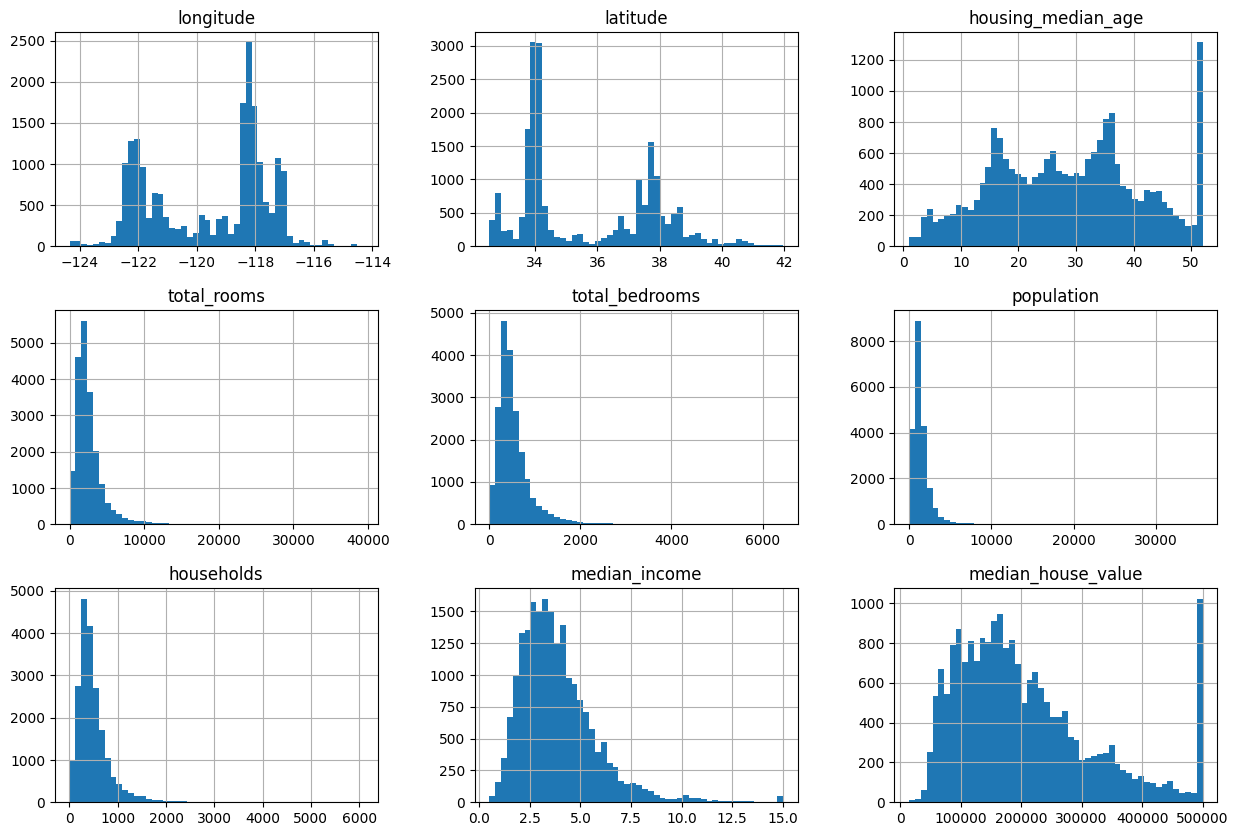

In [ ]:
df.hist(bins = 50,figsize= (15,10))

<Axes: >

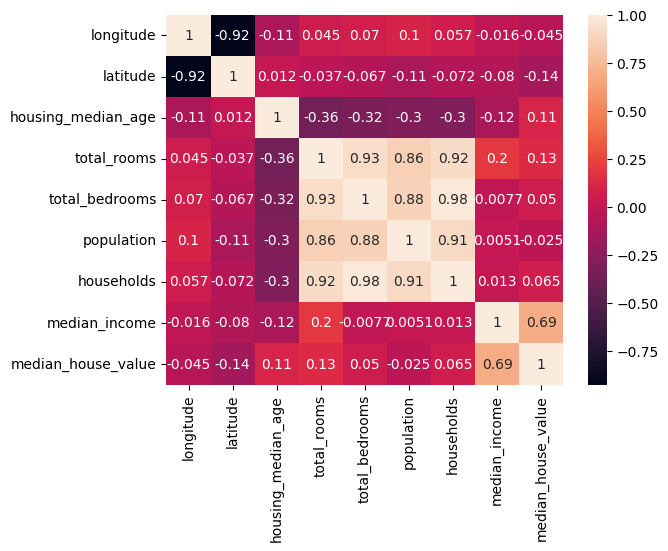

In [ ]:
# sns.heatmap(df.corr)
sns.heatmap(df.corr(numeric_only=True), annot = True)

<Axes: xlabel='latitude', ylabel='longitude'>

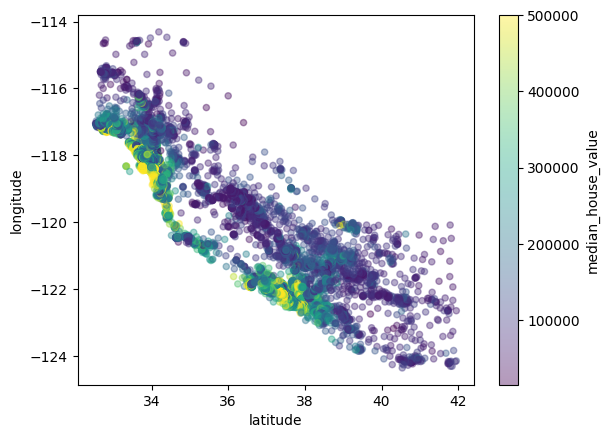

In [ ]:
df.plot(kind = "scatter",x = "latitude", y = "longitude", c="median_house_value", cmap="viridis", alpha=0.4)

#### Feature Engineering

In [ ]:
df["rooms_per_household"] = df["total_rooms"]/df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"]/df["total_rooms"]
df["population_per_household"] = df["population"]/df["households"]

#### Encodin

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [ ]:
df = df.drop(["ocean_proximity"], axis = 1)

KeyError: "['ocean_proximity'] not found in axis"

In [ ]:
X = df.drop(['median_house_value'], axis = 1)
y = df["median_house_value"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Fit and Transform

In [ ]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,6.281853,0.172096,2.181467


In [ ]:
from sklearn.preprocessing import StandardScaler



In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### model training

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
lr = LinearRegression()

In [ ]:
lr.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
y_pred = lr.predict(X_test_scaled)

## Accuracy

In [ ]:
from sklearn.metrics import r2_score

In [ ]:
accuracy = r2_score(y_test, y_pred)

In [ ]:
accuracy

0.6444552331796864